# Proposer: generated vs. expert hypothesis divergence

**LLM-as-a-judge** (`claude-sonnet-4-6`, "Sonnet 4.6", temperature 0) rates how *related* each model-generated hypothesis is to the dataset's **expert** (ground-truth) hypothesis for the same capsule.

The judge writes a **justification first**, then gives one of three ratings:

- `0` — **very related** (essentially the same claim)
- `1` — **partially related** (overlapping topic, different angle)
- `2` — **completely different** (a different claim — but still drawn from the same dataset)

Because both hypotheses come from the same dataset, the scale never means "unrelated science"; it spans "same claim" → "completely different claim from the same data".

Data source: the per-capsule trajectory JSONs written to `../proposer/` by `proposer/generate_hypotheses.py`.

In [2]:
import asyncio
import json
import os
from pathlib import Path

import pandas as pd
from lmi import LiteLLMModel
from pydantic import BaseModel

ROOT = Path("..")


def load_env(path: Path = ROOT / ".env") -> None:
    if not path.exists():
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip().strip('\"').strip("'"))


load_env()
JUDGE_MODEL = "claude-sonnet-4-6"
judge = LiteLLMModel(
    name=JUDGE_MODEL,
    config={
        "model_list": [
            {
                "model_name": JUDGE_MODEL,
                "litellm_params": {"model": JUDGE_MODEL, "reasoning_effort": "high"},
            }
        ],
    },
)
print("judge model:", JUDGE_MODEL)

judge model: claude-sonnet-4-6


## 1. Load generated + expert hypotheses

Reads every trajectory under `../proposer/` — including both `proposer/preview/` and `proposer/agent/` — so preview- and agent-mode hypotheses are judged together and can be compared via the `mode` column. Each capsule has one expert hypothesis and several generated ones; we flatten to one `(expert, generated)` pair per generated hypothesis.

In [24]:
PROPOSER_DIR = ROOT / "proposer"
HYPOTHESES_PATHS = [PROPOSER_DIR / "preview" / "hypotheses_generated.json",
                    PROPOSER_DIR / "agent" / "hypotheses_generated.json"]

# Load both preview- and agent-mode hypotheses together so they can be compared via the `mode`
# column. Fall back to the file's parent-dir name for `mode` if a record doesn't carry one.
records = []
for path in HYPOTHESES_PATHS:
    for r in json.loads(path.read_text()):
        r.setdefault("mode", path.parent.name)
        records.append(r)

pairs = []
for r in records:
    expert = r.get("expert_hypothesis")
    if not expert or not r.get("hypotheses"):
        continue 
    for j, gen in enumerate(r["hypotheses"]):
        pairs.append({
            "capsule_id": r["capsule_id"],
            "mode": r.get("mode"),
            "hyp_idx": j,
            "expert": expert,
            "generated": gen,
        })

print(f"{len(records)} capsules -> {len(pairs)} (generated vs expert) pairs")
pairs[:1]

128 capsules -> 294 (generated vs expert) pairs


[{'capsule_id': '0f14ffa7-f02a-4d20-8142-dfc404195e56',
  'mode': 'preview',
  'hyp_idx': 0,
  'expert': 'Alzheimer’s disease patients can be stratified into molecular subtypes by brain gene expression, indicating distinct mechanisms and potential therapeutic targets.',
  'generated': 'APOE ε4 allele carriers (genotype 34 or 44) exhibit significantly higher expression of complement and neuroinflammatory genes (including CLU and CR1) compared to APOE ε3/ε3 homozygotes across individuals in this ROSMAP cohort.'}]

## 2. The judge

The judge compares the *underlying scientific claim* — biological question, variables/entities, and asserted direction/relationship — not surface wording. It returns a justification and a rating on a 3-level scale: `0` very related, `1` partially related, `2` completely different (higher = more different, but always within the same dataset).

In [20]:
from pydantic import ValidationError


class JudgeRating(BaseModel):
    justification: str
    rating: int 


JUDGE_INSTRUCTIONS = """\
You are an expert scientific reviewer comparing two hypotheses written for the SAME biological
dataset:
- EXPERT: the ground-truth hypothesis a domain expert wrote.
- GENERATED: a hypothesis proposed by an AI model.

Both hypotheses are necessarily grounded in the SAME dataset, so they can never be about
unrelated data. Judge only how DIFFERENT the GENERATED hypothesis is from the EXPERT hypothesis
in terms of the underlying scientific claim: the biological question, the variables/entities
involved, the direction/relationship asserted, and the scope. Ignore surface wording, phrasing,
and level of specificity unless they change the actual claim.

First write a concise justification (2-4 sentences). Then give an integer rating of 0, 1, or 2:
- 0 = very related: essentially the same claim (same question, variables, and direction), or only
      minor differences in scope or emphasis
- 1 = partially related: overlapping topic but a meaningfully different angle, variable, or
      relationship
- 2 = completely different: a different scientific claim with no shared question, variables, or
      relationship (still drawn from the same data)

Return ONLY JSON of the form {\"justification\": \"...\", \"rating\": <0-2>}."""


def build_judge_prompt(expert: str, generated: str) -> str:
    return (
        JUDGE_INSTRUCTIONS
        + f"\n\nEXPERT HYPOTHESIS:\n{expert}\n\nGENERATED HYPOTHESIS:\n{generated}\n"
    )


def _parse_rating(text: str) -> JudgeRating:
    """Parse a judge response, unwrapping any tool-call-style envelope."""
    data = json.loads(text[text.index("{"):])
    if "rating" not in data:
        for key in ("parameters", "input", "arguments"):
            inner = data.get(key)
            if isinstance(inner, str):
                inner = json.loads(inner)
            if isinstance(inner, dict) and "rating" in inner:
                data = inner
                break
    return JudgeRating.model_validate(data)


async def judge_one(expert: str, generated: str, retries: int = 3) -> tuple[JudgeRating, str | None]:
    """Return ``(rating, reasoning)`` — reasoning is the judge's thinking (None if thinking was off)."""
    prompt = build_judge_prompt(expert, generated)
    last_err: Exception | None = None
    for _ in range(retries):
        resp = await judge.call_single(prompt, output_type=JudgeRating, timeout=120)
        try:
            return _parse_rating(resp.text or ""), resp.reasoning_content
        except (ValidationError, ValueError, json.JSONDecodeError) as e:
            last_err = e
    raise last_err


## 3. Run the judge over every pair

In [21]:
sem = asyncio.Semaphore(5)


async def run(p: dict) -> dict:
    async with sem:
        try:
            r, reasoning = await judge_one(p["expert"], p["generated"])
            return {**p, "rating": r.rating, "justification": r.justification, "reasoning": reasoning}
        except Exception as e:
            return {**p, "rating": None, "justification": f"ERROR: {type(e).__name__}: {e}", "reasoning": None}


results = await asyncio.gather(*(run(p) for p in pairs))
df = pd.DataFrame(results)
print("judged", len(df), "pairs")
df[["capsule_id", "hyp_idx", "rating", "reasoning"]]

/home/wangsaja/.conda/envs/bixbench/lib/python3.12/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected 9 fields but got 5: Expected `Message` - serialized value may not be as expected [field_name='choices', input_value=Message(content='{}', rol...er_specific_fields=None), input_type=Message])
  PydanticSerializationUnexpectedValue(Expected `StreamingChoices` - serialized value may not be as expected [field_name='choices', input_value=Choices(finish_reason='st...r_specific_fields=None)), input_type=Choices])
  return self.__pydantic_serializer__.to_python(
/home/wangsaja/.conda/envs/bixbench/lib/python3.12/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected 9 fields but got 5: Expected `Message` - serialized value may not be as expected [field_name='choices', input_value=Message(content=None, rol...thinking_blocks': None}), input_type=Mess

judged 294 pairs


,capsule_id,hyp_idx,rating,reasoning
0,0f14ffa7-f02a-4d20-8142-dfc404195e56,0,1.0,None
1,0f14ffa7-f02a-4d20-8142-dfc404195e56,1,1.0,None
2,0f14ffa7-f02a-4d20-8142-dfc404195e56,2,1.0,None
3,15ff11e5-2db1-45b6-b3a3-46bc2a74b821,0,1.0,None
4,15ff11e5-2db1-45b6-b3a3-46bc2a74b821,1,2.0,None
...,...,...,...,...
289,fbe0e950-76f2-4eb7-a216-a2d377970922,1,1.0,None
290,fbe0e950-76f2-4eb7-a216-a2d377970922,2,2.0,None
291,ff43cd5b-6f9e-410b-8d53-a5bb11b5b531,0,1.0,None
292,ff43cd5b-6f9e-410b-8d53-a5bb11b5b531,1,1.0,None


In [22]:
# Save under proposer/ (covers both the preview + agent records loaded above).
COMPARISON_PATH = PROPOSER_DIR / "comparison.json"
COMPARISON_PATH.write_text(json.dumps(results, indent=2))
print(f"wrote {len(results)} judged pairs -> {COMPARISON_PATH}")

wrote 294 judged pairs -> ../proposer/comparison.json


## 4. Per-hypothesis ratings + justifications

In [23]:
LABELS = {0: "very related", 1: "partially related", 2: "completely different"}

for _, row in df.iterrows():
    label = LABELS.get(row["rating"], "ERROR") if pd.notna(row["rating"]) else "ERROR"
    print(f"[{row['capsule_id'][:8]}] hyp #{row['hyp_idx']}  ->  rating = {row['rating']} / 2 ({label})")
    print("EXPERT   :", row["expert"])
    print("GENERATED:", row["generated"])
    print("JUDGE    :", row["justification"])
    print()

[0f14ffa7] hyp #0  ->  rating = 1.0 / 2 (partially related)
EXPERT   : Alzheimer’s disease patients can be stratified into molecular subtypes by brain gene expression, indicating distinct mechanisms and potential therapeutic targets.
GENERATED: APOE ε4 allele carriers (genotype 34 or 44) exhibit significantly higher expression of complement and neuroinflammatory genes (including CLU and CR1) compared to APOE ε3/ε3 homozygotes across individuals in this ROSMAP cohort.
JUDGE    : Both hypotheses involve brain gene expression in an AD cohort (ROSMAP), but the scientific claims are meaningfully different. The expert hypothesis centers on unsupervised molecular stratification of AD patients into subtypes with distinct mechanisms and therapeutic targets, whereas the generated hypothesis tests a specific genotype-driven differential expression relationship (APOE ε4 vs. ε3/ε3) for particular gene families (complement/neuroinflammatory: CLU, CR1). The expert's claim is about patient subtyping, 

## 5. Aggregate: how different overall?

overall mean difference rating: 0.66 / 1  (n=292)

by mode:


,mean,sem,count
mode,,,
agent,0.640,0.024,146
preview,0.675,0.023,146


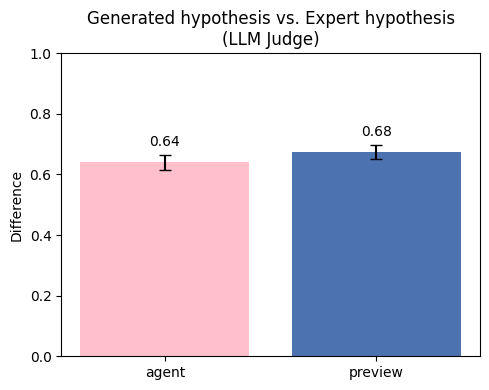

In [21]:
import matplotlib.pyplot as plt

valid = df[df["rating"].notna()].copy()
# Normalize the 0-2 judge rating onto a 0-1 scale (0 = very related … 1 = completely different).
valid["rating_norm"] = valid["rating"] / 2
print(f"overall mean difference rating: {valid['rating_norm'].mean():.2f} / 1  (n={len(valid)})")

per_mode = valid.groupby("mode")["rating_norm"].agg(["mean", "sem", "count"]).round(3)
print("\nby mode:")
display(per_mode)

# Compare the mean normalized difference rating between agent and preview modes.
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(per_mode.index, per_mode["mean"], yerr=per_mode["sem"], capsize=4,
       color=["pink", "#4c72b0"])
for i, (m, row) in enumerate(per_mode.iterrows()):
    # Sit the label just above the top of the error bar so they don't overlap.
    ax.text(i, row["mean"] + row["sem"] + 0.02, f"{row['mean']:.2f}", ha="center", va="bottom")
ax.set(title="Generated hypothesis vs. Expert hypothesis\n(LLM Judge)",
       ylabel="Difference",
       ylim=(0, 1))
plt.tight_layout()
plt.show()

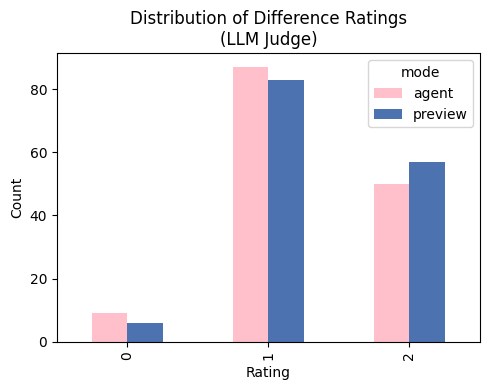

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json("../proposer/comparison.json")
valid = df[df["rating"].notna()].copy()

fig, ax = plt.subplots(figsize=(5, 4))

# Count occurrences of each rating (0,1,2) per mode
counts = valid.groupby(["mode", "rating"]).size().unstack(fill_value=0)
counts = counts.reindex(columns=[0, 1, 2], fill_value=0)

counts.T.plot(kind="bar", ax=ax, color=["pink", "#4c72b0"])

ax.set(title="Distribution of Difference Ratings\n(LLM Judge)",
       xlabel="Rating",
       ylabel="Count")
ax.legend(title="mode")
plt.tight_layout()
plt.show()

## 6. Alternative: semantic embedding similarity

Instead of (well, *alongside*) the LLM judge, we can score relatedness deterministically with **embedding cosine similarity**. Every distinct hypothesis string is embedded once with OpenAI `text-embedding-3-large`, and each `(expert, generated)` pair is scored by cosine similarity of their vectors.

- similarity near **1.0** → essentially the same claim
- lower similarity → an increasingly different claim (still from the same dataset)

This adds a `similarity` column to the existing `df` (it does **not** touch the judge `rating`), so the two signals can be compared directly below.

In [25]:
import numpy as np
from openai import AsyncOpenAI

EMBED_MODEL = "text-embedding-3-large"
embed_client = AsyncOpenAI()


async def embed_texts(texts: list[str], batch: int = 100) -> dict[str, np.ndarray]:
    vecs: dict[str, np.ndarray] = {}
    uniq = sorted(set(texts))
    for i in range(0, len(uniq), batch):
        chunk = uniq[i:i + batch]
        resp = await embed_client.embeddings.create(model=EMBED_MODEL, input=chunk)
        for text, d in zip(chunk, resp.data):
            v = np.asarray(d.embedding, dtype=np.float32)
            vecs[text] = v / (np.linalg.norm(v) + 1e-12)
    return vecs


vecs = await embed_texts([t for p in pairs for t in (p["expert"], p["generated"])])
df["similarity"] = [float(vecs[p["expert"]] @ vecs[p["generated"]]) for p in pairs]

print(f"embedded {len(vecs)} distinct hypotheses with {EMBED_MODEL}")
df[["capsule_id", "hyp_idx", "rating", "similarity"]].round(3)

embedded 343 distinct hypotheses with text-embedding-3-large


,capsule_id,hyp_idx,rating,similarity
0,0f14ffa7-f02a-4d20-8142-dfc404195e56,0,1.0,0.433
1,0f14ffa7-f02a-4d20-8142-dfc404195e56,1,1.0,0.427
2,0f14ffa7-f02a-4d20-8142-dfc404195e56,2,1.0,0.534
3,15ff11e5-2db1-45b6-b3a3-46bc2a74b821,0,1.0,0.330
4,15ff11e5-2db1-45b6-b3a3-46bc2a74b821,1,2.0,0.266
...,...,...,...,...
289,fbe0e950-76f2-4eb7-a216-a2d377970922,1,1.0,0.542
290,fbe0e950-76f2-4eb7-a216-a2d377970922,2,2.0,0.526
291,ff43cd5b-6f9e-410b-8d53-a5bb11b5b531,0,1.0,0.455
292,ff43cd5b-6f9e-410b-8d53-a5bb11b5b531,1,1.0,0.455


by mode (embedding dissimilarity = 1 - cosine similarity):


,mean,sem,count
mode,,,
agent,0.471,0.013,147
preview,0.481,0.013,147


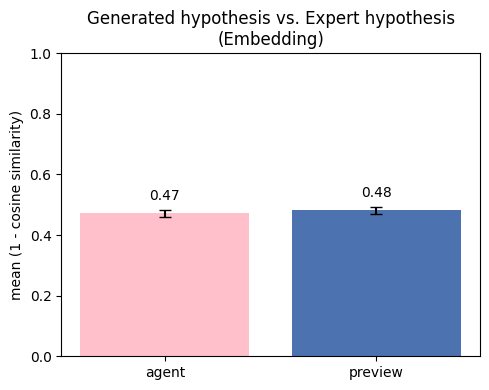

In [27]:
import matplotlib.pyplot as plt

# Convert cosine similarity to a divergence (1 - similarity) so it matches the judge scale:
# 1 = completely different, 0 = exactly the same.
sim = df[df["similarity"].notna()].copy()
sim["dissimilarity"] = 1 - sim["similarity"]

per_mode_sim = sim.groupby("mode")["dissimilarity"].agg(["mean", "sem", "count"]).round(3)
print("by mode (embedding dissimilarity = 1 - cosine similarity):")
display(per_mode_sim)

# Compare the mean embedding dissimilarity between agent and preview modes.
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(per_mode_sim.index, per_mode_sim["mean"], yerr=per_mode_sim["sem"], capsize=4,
       color=["pink", "#4c72b0"])
for i, (m, row) in enumerate(per_mode_sim.iterrows()):
    # Sit the label just above the top of the error bar so they don't overlap.
    ax.text(i, row["mean"] + row["sem"] + 0.02, f"{row['mean']:.2f}", ha="center", va="bottom")
ax.set(title="Generated hypothesis vs. Expert hypothesis\n(Embedding)",
       ylabel="mean (1 - cosine similarity)",
       ylim=(0, 1))
plt.tight_layout()
plt.show()

## 7. Compare: LLM judge vs embedding similarity

Do the two signals agree? The judge rating goes **up** with difference (0→2) while cosine similarity goes **down**, so we expect a **negative** correlation. Below: Spearman correlation, mean embedding similarity within each judge bucket, and a scatter.

Spearman corr (judge rating vs embedding similarity): -0.70  (n=292)
(negative expected)

mean embedding similarity per judge rating:


,mean,count
rating,,
0.0,0.707,15
1.0,0.591,170
2.0,0.393,107


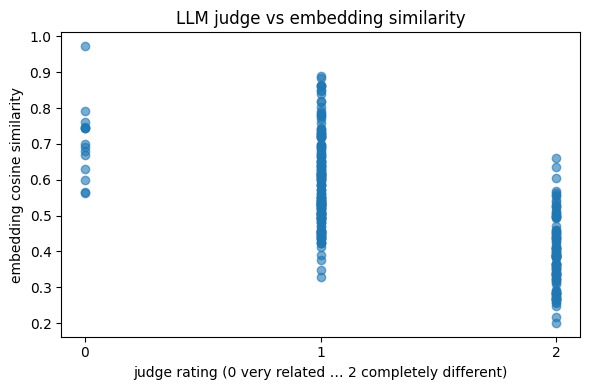

In [34]:
import matplotlib.pyplot as plt

cmp = df[df["rating"].notna()].copy()
corr = cmp["rating"].corr(cmp["similarity"], method="spearman")
print(f"Spearman corr (judge rating vs embedding similarity): {corr:.2f}  (n={len(cmp)})")
print("(negative expected)")

print("\nmean embedding similarity per judge rating:")
display(cmp.groupby("rating")["similarity"].agg(["mean", "count"]).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(cmp["rating"], cmp["similarity"], alpha=0.6)
ax.set(title="LLM judge vs embedding similarity",
       xlabel="judge rating (0 very related … 2 completely different)",
       ylabel="embedding cosine similarity", xticks=[0, 1, 2])
plt.tight_layout()
plt.show()

# Check what makes the Bixbench (original) hypotheses good
Is it the data or the hypothesis?

In [7]:
import pandas as pd

df = pd.read_json("../bixbench.jsonl", lines=True)

In [8]:
df

,id,tag,version,question,ideal,distractors,canary,capsule_uuid,short_id,question_id,hypothesis,result,answer,categories,paper,data_folder,eval_mode
0,a32935af-103a-49d5-bb51-134052afe409,bixbench,1.5,Using the provided RNA-seq count data and meta...,0.0002,"[7.820659E-05, 0.0003, 1.847038E-05]",BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINING...,33b801bb-9b47-4a0a-9314-05325c82fde7,bix-1,bix-1-q1,Truncating ASXL1 mutations will lead to specif...,Gene ontology (GO) analysis of differentially ...,True,"RNA-seq,Differential Expression Analysis,Trans...",https://doi.org/10.1172/jci.insight.167744,CapsuleFolder-33b801bb-9b47-4a0a-9314-05325c82...,str_verifier
1,e40e8b38-81a6-4984-946c-e1a1948188df,bixbench,1.5,What is the adjusted p-val threshold for neutr...,1.9E-05,"[3.23E-08, 4.56E-04, 2.15E-06]",BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINING...,33b801bb-9b47-4a0a-9314-05325c82fde7,bix-1,bix-1-q2,Truncating ASXL1 mutations will lead to specif...,Gene ontology (GO) analysis of differentially ...,True,"RNA-seq,Differential Expression Analysis,Trans...",https://doi.org/10.1172/jci.insight.167744,CapsuleFolder-33b801bb-9b47-4a0a-9314-05325c82...,str_verifier
2,a3c86017-84bd-47a0-9a06-1f18564fde2b,bixbench,1.5,What is the odds ratio of higher COVID-19 seve...,"(1.50,1.54)","[(0.66,0.70), (0.95,1.05), (1.24,1.28)]",BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINING...,fbe0e950-76f2-4eb7-a216-a2d377970922,bix-10,bix-10-q1,Tubercolosis BCG re-vaccination reduces COVID-...,Statistical analysis suggests that the BCG vac...,False,Other,https://zenodo.org/records/12737228,CapsuleFolder-fbe0e950-76f2-4eb7-a216-a2d37797...,range_verifier
3,ccde55e4-4cb0-4434-a1d7-a5f07657c0e4,bixbench,1.5,Using an ordinal logistic regression model (or...,"(0.74,0.77)","[(1.24,1.28), (0.26,0.28), (0.95,1.05)]",BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINING...,fbe0e950-76f2-4eb7-a216-a2d377970922,bix-10,bix-10-q2,Tubercolosis BCG re-vaccination reduces COVID-...,Statistical analysis suggests that the BCG vac...,False,Other,https://zenodo.org/records/12737228,CapsuleFolder-fbe0e950-76f2-4eb7-a216-a2d37797...,range_verifier
4,31db10bf-857a-4a39-91fa-9ea15d59c5b3,bixbench,1.5,In which patient volume group (number of patie...,1-50,"[51-100, >100, 1-100]",BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINING...,fbe0e950-76f2-4eb7-a216-a2d377970922,bix-10,bix-10-q3,Tubercolosis BCG re-vaccination reduces COVID-...,Statistical analysis suggests that the BCG vac...,False,Other,https://zenodo.org/records/12737228,CapsuleFolder-fbe0e950-76f2-4eb7-a216-a2d37797...,str_verifier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,ed37313e-46c6-4c10-bddd-417118e4f7d3,bixbench,1.5,How many genes show significant hypermethylati...,680,"[511, 11563, 415]",BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINING...,48a6b469-9c9d-4bef-b5b4-f29b7d6fa046,bix-8,bix-8-q6,mRNA m6A methylation plays a significant role ...,'- we analyzed a table provided by the origina...,True,"Epigenomics,Differential Expression Analysis,R...",10.17632/dj4sb8h3c3.1,CapsuleFolder-48a6b469-9c9d-4bef-b5b4-f29b7d6f...,str_verifier
201,899f4509-73fb-4ff8-9063-7b1e1ddc7b79,bixbench,1.5,How many genes exhibit both m6a hypermethylati...,106,"[12, 562, 383]",BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINING...,48a6b469-9c9d-4bef-b5b4-f29b7d6fa046,bix-8,bix-8-q7,mRNA m6A methylation plays a significant role ...,'- we analyzed a table provided by the origina...,True,"Epigenomics,Differential Expression Analysis,R...",10.17632/dj4sb8h3c3.1,CapsuleFolder-48a6b469-9c9d-4bef-b5b4-f29b7d6f...,str_verifier
202,37bf341a-0ff3-497d-a66f-c18ffb33b84f,bixbench,1.5,"In the dentate gyrus, what is the pattern of s...",No overlap between any groups,"[Complete overlap between all groups, Partial ...",BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINING...,873bada5-b1f3-423a-87dc-9ddd486c4843,bix-9,bix-9-q3,Paroxetine induces tissue-specific gene expres...,ANOVA analysis across tissues and responses po...,True,"Differential Expression An

# 9. Rubric category distributions: original vs. LLM-generated

Every grading rubric criterion is tagged with one or more `categories` — a criterion can span more than one axis at once (e.g. checking both data loading AND a statistical test), so classification is **multi-label**, not one-to-one. Two rubric sources exist, both now reclassified with the multi-label prompt (`proposer/classify_original_rubrics.py` / `proposer/classify_rubric_criteria.py`):

- **`../original_rubrics.json`** — expert-authored rubrics, one per Bixbench capsule (51 capsules, one rubric each), avg. ~2.2 categories/criterion.
- **`../hypotheses_generated.json`** — rubrics the agent generated for its own proposed hypotheses (14 capsules that produced usable rubrics, up to 3 hypotheses/rubrics each -> 42 rubrics), avg. ~2.35 categories/criterion.

All **6** defined categories now appear (`data_handling`, `method_selection`, `statistical_rigor`, `biological_interpretation`, `scientific_reasoning`, `source_reliability`) — `source_reliability` is rare (2/341 original criteria, 0/278 generated).

For each rubric we compute, per category, the *fraction* of its criteria that touch that category (so a rubric with 6 criteria and a rubric with 8 contribute equally; a multi-label criterion counts toward every category it's tagged with, so these fractions need not sum to 1), then compare the original vs. generated distributions with:

1. A pooled **chi-square test of independence** (source × category, over every criterion-category pair) — a quick, liberal global test.
2. A **per-category Mann-Whitney U test** on the per-rubric proportions (rubric = independent unit), with **Benjamini-Hochberg FDR** correction across the 6 categories — the more statistically appropriate test since criteria within one rubric aren't independent draws.

In [15]:
import json

orig_raw = json.loads((ROOT / "original_rubrics.json").read_text())
# Two generated sources — preview- and agent-mode hypotheses — compared against the expert rubrics.
gen_raw = {
    "generated (preview)": json.loads((ROOT / "proposer" / "preview" / "hypotheses_generated.json").read_text()),
    "generated (agent)": json.loads((ROOT / "proposer" / "agent" / "hypotheses_generated.json").read_text()),
}


def crit_categories(c: dict) -> list[str]:
    """A criterion can span more than one category; fall back to the old single-label
    `category` field for any rubric not yet reclassified with the multi-label prompt."""
    return c["categories"] if "categories" in c else [c["category"]]


crit_rows = []
for cap in orig_raw:
    rid = f"orig::{cap['capsule_id']}"
    for c in cap["criteria"]:
        crit_rows.append({"rubric_id": rid, "capsule_id": cap["capsule_id"], "source": "original (expert)",
                           "categories": crit_categories(c), "points": c["points"]})

for source, raw in gen_raw.items():
    tag = source.split("(")[1].rstrip(")")  # "preview" / "agent"
    for cap in raw:
        for h, rub in enumerate(cap.get("rubrics") or []):
            rid = f"gen-{tag}::{cap['capsule_id']}::{h}"
            for c in rub["criteria"]:
                crit_rows.append({"rubric_id": rid, "capsule_id": cap["capsule_id"], "source": source,
                                   "categories": crit_categories(c), "points": c["points"]})

crit = pd.DataFrame(crit_rows)
crit["n_categories"] = crit["categories"].str.len()
CATEGORIES = sorted({cat for cats in crit["categories"] for cat in cats})
SOURCES = ["original (expert)", "generated (preview)", "generated (agent)"]

print(f"{len(CATEGORIES)} categories: {CATEGORIES}")
print(f"{crit['rubric_id'].nunique()} rubrics, {len(crit)} criteria total, "
      f"avg {crit['n_categories'].mean():.2f} categories/criterion")
for s, g in crit.groupby("source"):
    print(f"  {s}: {len(g)} criteria across {g['rubric_id'].nunique()} rubrics ({g['capsule_id'].nunique()} capsules), "
          f"avg {g['n_categories'].mean():.2f} categories/criterion")

stale = [s for s, g in crit.groupby("source") if (g["n_categories"] == 1).all()]
if stale:
    print(f"\nWARNING: {stale} still has exactly 1 category per criterion — it hasn't been "
          "reclassified with the multi-label prompt yet (re-run scripts/classify_*.py). Comparisons "
          "below are confounded until every source is reclassified.")

# one row per (rubric, criterion, category) — a multi-label criterion appears once per category
crit_exp = crit.explode("categories").rename(columns={"categories": "category"})
crit.head()

6 categories: ['biological_interpretation', 'data_handling', 'method_selection', 'scientific_reasoning', 'source_reliability', 'statistical_rigor']
429 rubrics, 2805 criteria total, avg 2.40 categories/criterion
  generated (agent): 1233 criteria across 189 rubrics (63 capsules), avg 2.45 categories/criterion
  generated (preview): 1231 criteria across 189 rubrics (63 capsules), avg 2.40 categories/criterion
  original (expert): 341 criteria across 51 rubrics (51 capsules), avg 2.20 categories/criterion


,rubric_id,capsule_id,source,categories,points,n_categories
0,orig::33b801bb-9b47-4a0a-9314-05325c82fde7,33b801bb-9b47-4a0a-9314-05325c82fde7,original (expert),"[data_handling, method_selection]",1,2
1,orig::33b801bb-9b47-4a0a-9314-05325c82fde7,33b801bb-9b47-4a0a-9314-05325c82fde7,original (expert),"[method_selection, statistical_rigor]",1,2
2,orig::33b801bb-9b47-4a0a-9314-05325c82fde7,33b801bb-9b47-4a0a-9314-05325c82fde7,original (expert),"[statistical_rigor, method_selection]",1,2
3,orig::33b801bb-9b47-4a0a-9314-05325c82fde7,33b801bb-9b47-4a0a-9314-05325c82fde7,original (expert),"[method_selection, statistical_rigor]",1,2
4,orig::33b801bb-9b47-4a0a-9314-05325c82fde7,33b801bb-9b47-4a0a-9314-05325c82fde7,original (expert),"[biological_interpretation, scientific_reasoning]",1,2


### Per-rubric category proportions + plot

Compute, for every rubric, what fraction of its criteria fall in each category, then compare the two sources' mean composition.

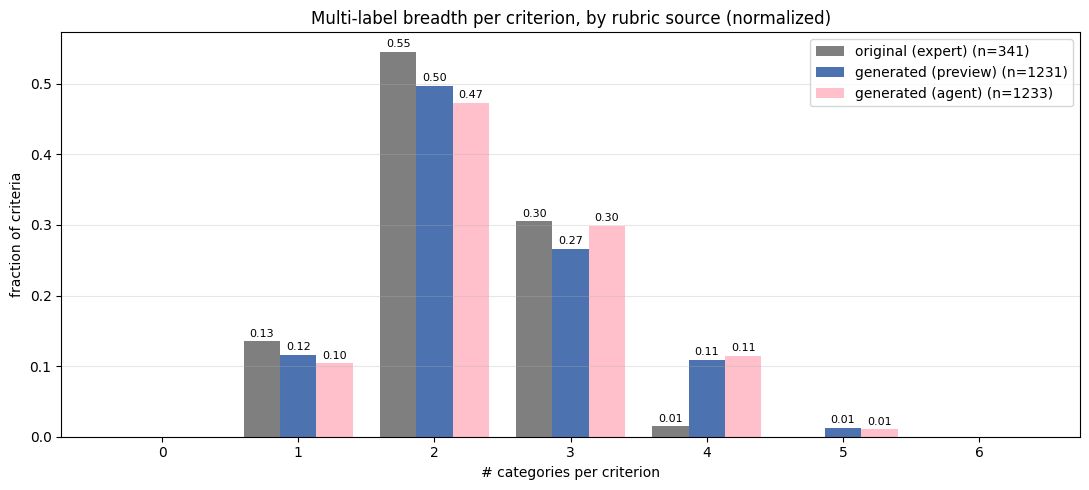

In [16]:
# Distribution of how many categories each criterion touches (len(categories)), all sources on one plot.
# x-axis: number of categories (0..len(CATEGORIES)); y-axis: fraction of criteria (each source sums to 1,
# so sources with different n are comparable); grouped bars by source.
colors = {"original (expert)": "#7f7f7f", "generated (preview)": "#4c72b0", "generated (agent)": "pink"}
bins = np.arange(0, len(CATEGORIES) + 1)  # 0..6
width = 0.8 / len(SOURCES)

fig, ax = plt.subplots(figsize=(11, 5))
for i, source in enumerate(SOURCES):
    n_cats = crit.loc[crit["source"] == source, "n_categories"]
    frac = n_cats.value_counts(normalize=True).reindex(bins, fill_value=0)
    offset = (i - (len(SOURCES) - 1) / 2) * width
    bars = ax.bar(bins + offset, frac.loc[bins], width, label=f"{source} (n={len(n_cats)})",
                  color=colors[source])
    ax.bar_label(bars, labels=[f"{f:.2f}" if f else "" for f in frac.loc[bins]], padding=2, fontsize=8)
ax.set(xticks=bins, xlabel="# categories per criterion", ylabel="fraction of criteria",
       title="Multi-label breadth per criterion, by rubric source (normalized)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

criteria per rubric (len(criteria)) by source:


,count,mean,std,min,max
source,,,,,
original (expert),51,6.69,1.05,5,10
generated (preview),189,6.51,0.61,5,8
generated (agent),189,6.52,0.57,5,8


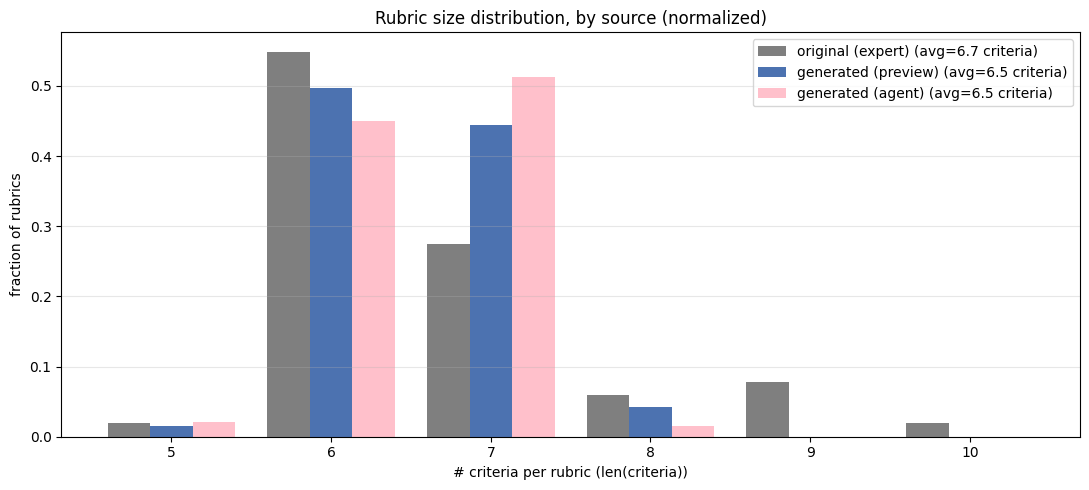

In [18]:
# Distribution of rubric SIZE — len(criteria) per rubric — for all three sources.
# x-axis: number of criteria in a rubric; y-axis: fraction of rubrics (each source sums to 1); grouped bars.

colors = {"original (expert)": "#7f7f7f", "generated (preview)": "#4c72b0", "generated (agent)": "pink"}

# criteria-per-rubric, tagged by source (one value per rubric)
rubric_size = (crit.groupby(["rubric_id", "source"]).size()
                   .reset_index(name="n_criteria"))
bins = np.arange(rubric_size["n_criteria"].min(), rubric_size["n_criteria"].max() + 1)
width = 0.8 / len(SOURCES)

print("criteria per rubric (len(criteria)) by source:")
display(rubric_size.groupby("source")["n_criteria"].agg(["count", "mean", "std", "min", "max"]).reindex(SOURCES).round(2))

fig, ax = plt.subplots(figsize=(11, 5))
for i, source in enumerate(SOURCES):
    sizes = rubric_size.loc[rubric_size["source"] == source, "n_criteria"]
    frac = sizes.value_counts(normalize=True).reindex(bins, fill_value=0)
    offset = (i - (len(SOURCES) - 1) / 2) * width
    ax.bar(bins + offset, frac.loc[bins], width, label=f"{source} (avg={sizes.mean():.1f} criteria)",
           color=colors[source])
ax.set(xticks=bins, xlabel="# criteria per rubric (len(criteria))", ylabel="fraction of rubrics",
       title="Rubric size distribution, by source (normalized)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

mean per-rubric category proportions (a multi-label criterion counts toward every category it touches, so a rubric's row need not sum to 1):


category,biological_interpretation,data_handling,method_selection,scientific_reasoning,source_reliability,statistical_rigor
source,,,,,,
original (expert),0.309,0.374,0.482,0.352,0.005,0.685
generated (preview),0.308,0.423,0.559,0.386,0.015,0.708
generated (agent),0.319,0.423,0.585,0.385,0.008,0.737


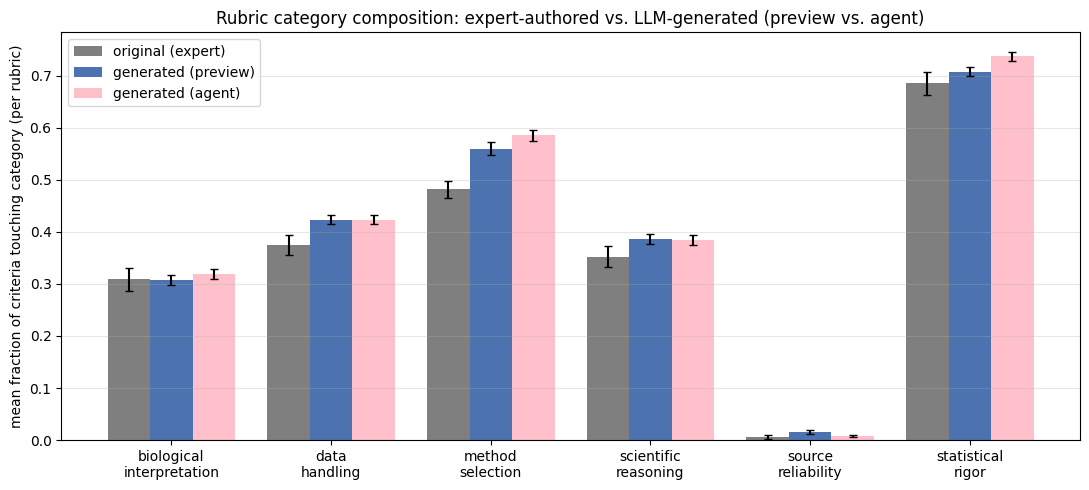

In [19]:
import numpy as np
import matplotlib.pyplot as plt


n_per_rubric = crit.groupby(["rubric_id", "source"]).size()
counts = (crit_exp.pivot_table(index=["rubric_id", "source"], columns="category", values="points",
                                aggfunc="count", fill_value=0)
              .reindex(columns=CATEGORIES, fill_value=0))
props = counts.div(n_per_rubric, axis=0).reset_index()

mean_props = props.groupby("source")[CATEGORIES].mean().reindex(SOURCES)
sem_props = props.groupby("source")[CATEGORIES].sem().reindex(SOURCES)
print("mean per-rubric category proportions (a multi-label criterion counts toward every category it "
      "touches, so a rubric's row need not sum to 1):")
display(mean_props.round(3))

x = np.arange(len(CATEGORIES))
width = 0.8 / len(SOURCES)
colors = {"original (expert)": "#7f7f7f", "generated (preview)": "#4c72b0", "generated (agent)": "pink"}

fig, ax = plt.subplots(figsize=(11, 5))
for i, source in enumerate(SOURCES):
    offset = (i - (len(SOURCES) - 1) / 2) * width
    ax.bar(x + offset, mean_props.loc[source], width, yerr=sem_props.loc[source],
           label=source, color=colors[source], capsize=3)
ax.set(xticks=x, xticklabels=[c.replace("_", "\n") for c in CATEGORIES],
       ylabel="mean fraction of criteria touching category (per rubric)",
       title="Rubric category composition: expert-authored vs. LLM-generated (preview vs. agent)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Are the distributions significantly different?

In [20]:
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.multitest import multipletests

GEN_SOURCES = ["generated (preview)", "generated (agent)"]
o = props[props["source"] == "original (expert)"]

# Compare each generated source separately against the expert baseline.
for gen_source in GEN_SOURCES:
    g = props[props["source"] == gen_source]
    print(f"\n{'='*80}\n{gen_source}  vs  original (expert)\n{'='*80}")

    # 1. pooled chi-square test of independence (source x category), over every (criterion, category) pair
    pair = crit_exp[crit_exp["source"].isin(["original (expert)", gen_source])]
    contingency = pair.groupby(["source", "category"]).size().unstack(fill_value=0).reindex(columns=CATEGORIES)
    chi2, p_chi2, dof, expected = chi2_contingency(contingency)
    print("contingency table (criterion-category pair counts; a multi-label criterion is counted once per category):")
    display(contingency)
    print(f"chi-square test of independence: chi2={chi2:.2f}, dof={dof}, p={p_chi2:.4f}")
    print("(liberal test: criteria within a rubric aren't independent draws, and a multi-label criterion is "
          "double-/triple-counted across its categories — treat as descriptive.)")

    # 2. per-category Mann-Whitney U on per-rubric proportions, BH-FDR corrected across categories
    rows = []
    for cat in CATEGORIES:
        u, p = mannwhitneyu(o[cat], g[cat], alternative="two-sided")
        rows.append({"category": cat, "orig_mean": o[cat].mean(), "gen_mean": g[cat].mean(), "U": u, "p": p})
    res = pd.DataFrame(rows)
    res["p_fdr"] = multipletests(res["p"], method="fdr_bh")[1]
    res["significant (fdr<0.05)"] = res["p_fdr"] < 0.05

    print(f"\nper-category Mann-Whitney U, rubric-level (n_orig={len(o)}, n_gen={len(g)}), BH-FDR corrected:")
    display(res.round(4))


generated (preview)  vs  original (expert)
contingency table (criterion-category pair counts; a multi-label criterion is counted once per category):


category,biological_interpretation,data_handling,method_selection,scientific_reasoning,source_reliability,statistical_rigor
source,,,,,,
generated (preview),382,520,695,473,19,870
original (expert),104,127,166,117,2,234


chi-square test of independence: chi2=3.23, dof=5, p=0.6651
(liberal test: criteria within a rubric aren't independent draws, and a multi-label criterion is double-/triple-counted across its categories — treat as descriptive.)

per-category Mann-Whitney U, rubric-level (n_orig=51, n_gen=189), BH-FDR corrected:


,category,orig_mean,gen_mean,U,p,p_fdr,significant (fdr<0.05)
0,biological_interpretation,0.3086,0.3078,4839.5,0.9642,0.9642,False
1,data_handling,0.3745,0.4234,3674.0,0.0082,0.0247,True
2,method_selection,0.4815,0.5595,3199.0,0.0002,0.0012,True
3,scientific_reasoning,0.3519,0.3862,4041.5,0.0717,0.1433,False
4,source_reliability,0.0053,0.0151,4538.0,0.1825,0.2738,False
5,statistical_rigor,0.6850,0.7078,4553.0,0.5388,0.6465,False



generated (agent)  vs  original (expert)
contingency table (criterion-category pair counts; a multi-label criterion is counted once per category):


category,biological_interpretation,data_handling,method_selection,scientific_reasoning,source_reliability,statistical_rigor
source,,,,,,
generated (agent),394,521,724,471,10,907
original (expert),104,127,166,117,2,234


chi-square test of independence: chi2=1.55, dof=5, p=0.9071
(liberal test: criteria within a rubric aren't independent draws, and a multi-label criterion is double-/triple-counted across its categories — treat as descriptive.)

per-category Mann-Whitney U, rubric-level (n_orig=51, n_gen=189), BH-FDR corrected:


,category,orig_mean,gen_mean,U,p,p_fdr,significant (fdr<0.05)
0,biological_interpretation,0.3086,0.3194,4601.5,0.6166,0.6669,False
1,data_handling,0.3745,0.4233,3760.0,0.0144,0.0349,True
2,method_selection,0.4815,0.5851,2836.5,0.0000,0.0000,True
3,scientific_reasoning,0.3519,0.3846,4158.5,0.1265,0.1897,False
4,source_reliability,0.0053,0.0078,4747.5,0.6669,0.6669,False
5,statistical_rigor,0.6850,0.7371,3788.5,0.0174,0.0349,True


In [1]:
print("test")

test
